**Import  Libraries**

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

from statsmodels.tsa.arima.model import ARIMA
from xgboost import XGBRegressor

In [25]:
!pip install prophet

In [26]:
from prophet import Prophet

**Load Dataset**

In [27]:
df = pd.read_csv('/content/household_power_consumption.csv',sep=',',
    parse_dates={'Datetime': ['Date', 'Time']},
    infer_datetime_format=True,
    low_memory=False
)

/tmp/ipykernel_5374/3174751967.py:1: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv('/content/household_power_consumption.csv',sep=',',
/tmp/ipykernel_5374/3174751967.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv('/content/household_power_consumption.csv',sep=',',
/tmp/ipykernel_5374/3174751967.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv('/content/household_power_consumption.csv',sep=',',


In [28]:
df.head()

,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,2006-12-16 17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


**Data Cleaning**

In [29]:
df.replace('?', np.nan, inplace=True)
df = df.dropna()

# Convert to numeric
df['Global_active_power'] = df['Global_active_power'].astype(float)

df.set_index('Datetime', inplace=True)

**Resample Time Series**

/tmp/ipykernel_5374/2211002937.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df['Global_active_power'].resample('H').mean()


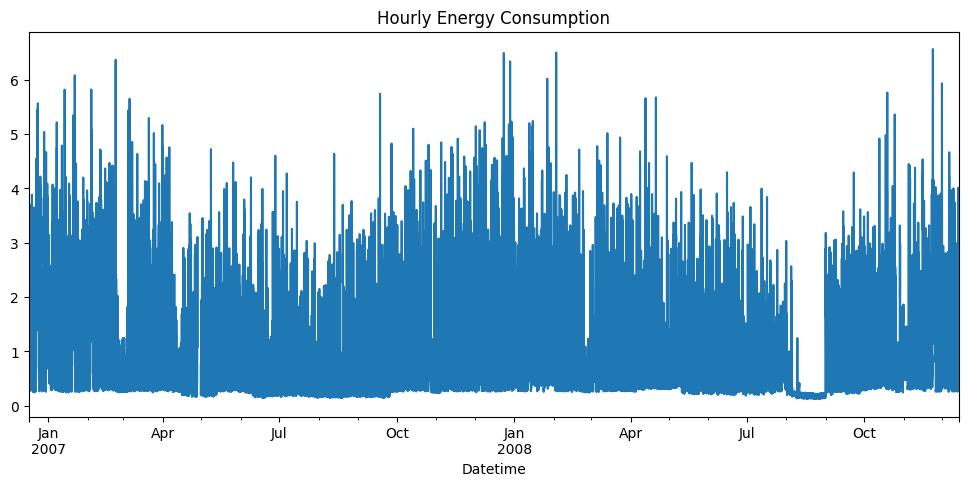

In [30]:
df_hourly = df['Global_active_power'].resample('H').mean()

df_hourly.plot(figsize=(12,5), title='Hourly Energy Consumption')
plt.show()

**Feature Engineering**

In [31]:
df_feat = df_hourly.to_frame()

df_feat['hour'] = df_feat.index.hour
df_feat['day'] = df_feat.index.day
df_feat['month'] = df_feat.index.month
df_feat['weekday'] = df_feat.index.weekday

# Weekend feature
df_feat['is_weekend'] = df_feat['weekday'].apply(lambda x: 1 if x >=5 else 0)

df_feat.head()

,Global_active_power,hour,day,month,weekday,is_weekend
Datetime,,,,,,
2006-12-16 17:00:00,4.222889,17,16,12,5,1
2006-12-16 18:00:00,3.632200,18,16,12,5,1
2006-12-16 19:00:00,3.400233,19,16,12,5,1
2006-12-16 20:00:00,3.268567,20,16,12,5,1
2006-12-16 21:00:00,3.056467,21,16,12,5,1


**Train-Test Split**

In [32]:
train_size = int(len(df_feat) * 0.6)

train = df_feat[:train_size]
test = df_feat[train_size:]

**ARIMA Model**

In [33]:
arima_model = ARIMA(train['Global_active_power'], order=(5,1,0))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(test))

**Prophet Model**

In [34]:
prophet_df = df_hourly.reset_index()
prophet_df.columns = ['ds', 'y']

train_p = prophet_df[:train_size]
test_p = prophet_df[train_size:]

model = Prophet()
model.fit(train_p)

future = model.make_future_dataframe(periods=len(test), freq='H')
forecast = model.predict(future)

prophet_pred = forecast['yhat'][-len(test):].values

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


**XGBoost Model**

In [35]:
features = ['hour', 'day', 'month', 'weekday', 'is_weekend']

X_train = train[features]
y_train = train['Global_active_power']

X_test = test[features]
y_test = test['Global_active_power']

# Identify problematic values (NaN or infinity) in y_train
problematic_y_train = y_train.isnull() | np.isinf(y_train)
if problematic_y_train.any():
    print(f"Warning: {problematic_y_train.sum()} problematic values (NaN or inf) found in y_train. Dropping corresponding rows from X_train and y_train.")
    X_train = X_train[~problematic_y_train]
    y_train = y_train[~problematic_y_train]

# Identify problematic values (NaN or infinity) in y_test
problematic_y_test = y_test.isnull() | np.isinf(y_test)
if problematic_y_test.any():
    print(f"Warning: {problematic_y_test.sum()} problematic values (NaN or inf) found in y_test. Dropping corresponding rows from X_test and y_test.")
    X_test = X_test[~problematic_y_test]
    y_test = y_test[~problematic_y_test]

xgb = XGBRegressor(n_estimators=100)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

**Evaluate Models**

In [36]:
# Evaluate ARIMA
rmse_arima = np.sqrt(mean_squared_error(y_test, arima_pred))
mae_arima = mean_absolute_error(y_test, arima_pred)

# Evaluate Prophet
rmse_prophet = np.sqrt(mean_squared_error(y_test, prophet_pred))
mae_prophet = mean_absolute_error(y_test, prophet_pred)

# Evaluate XGBoost
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
mae_xgb = mean_absolute_error(y_test, xgb_pred)

print(f"ARIMA RMSE: {rmse_arima:.3f}, MAE: {mae_arima:.3f}")
print(f"Prophet RMSE: {rmse_prophet:.3f}, MAE: {mae_prophet:.3f}")
print(f"XGBoost RMSE: {rmse_xgb:.3f}, MAE: {mae_xgb:.3f}")

ARIMA RMSE: 0.960, MAE: 0.662
Prophet RMSE: 0.808, MAE: 0.611
XGBoost RMSE: 0.769, MAE: 0.550


**Plot**

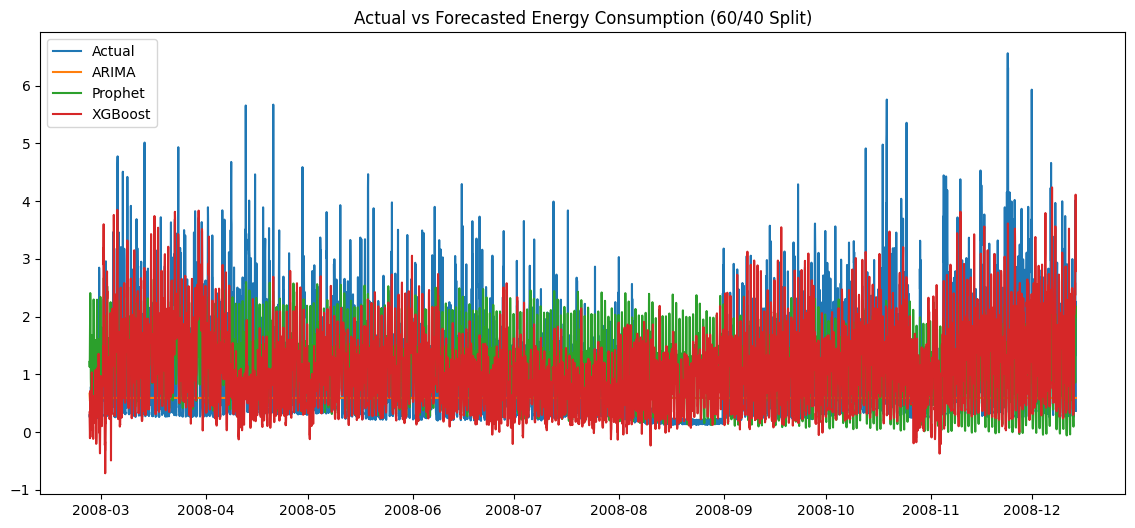

In [37]:
plt.figure(figsize=(14,6))

plt.plot(test.index, y_test, label='Actual')
plt.plot(test.index, arima_pred, label='ARIMA')
plt.plot(test.index, prophet_pred, label='Prophet')
plt.plot(test.index, xgb_pred, label='XGBoost')

plt.legend()
plt.title('Actual vs Forecasted Energy Consumption (60/40 Split)')
plt.show()

**Separate Plots**

**ARIMA**

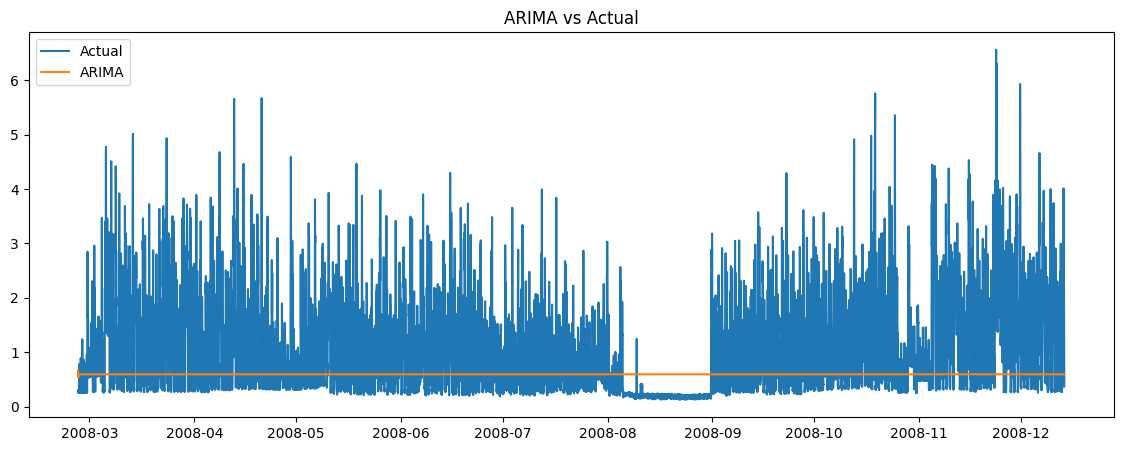

In [38]:
plt.figure(figsize=(14,5))
plt.plot(test.index, y_test, label='Actual')
plt.plot(test.index, arima_pred, label='ARIMA')

plt.legend()
plt.title('ARIMA vs Actual')
plt.show()

**Prophet**

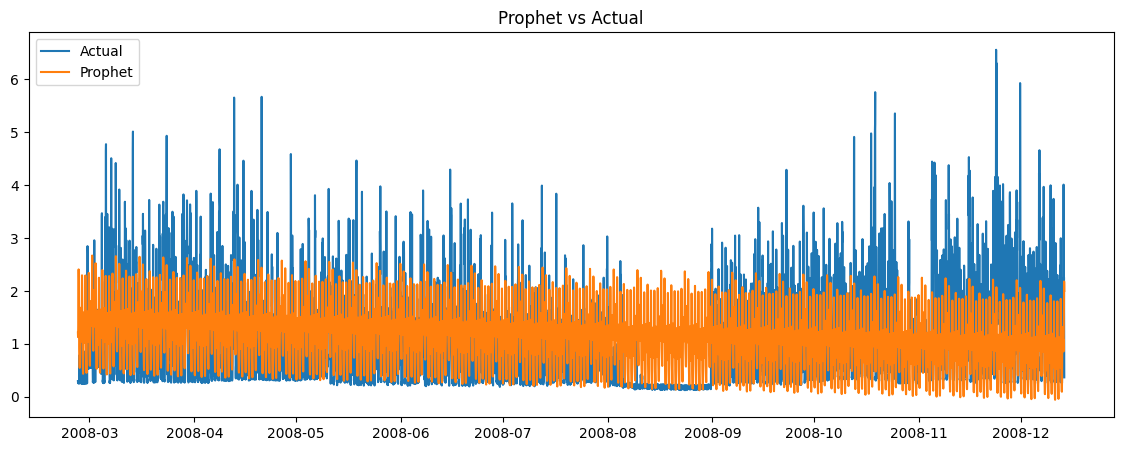

In [39]:
plt.figure(figsize=(14,5))
plt.plot(test.index, y_test, label='Actual')
plt.plot(test.index, prophet_pred, label='Prophet')

plt.legend()
plt.title('Prophet vs Actual')
plt.show()

**XGBoost**

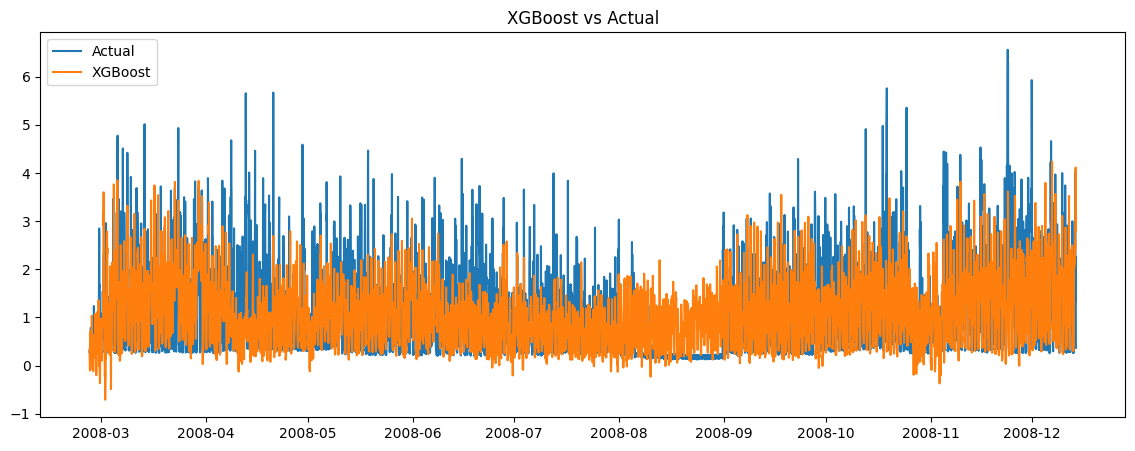

In [40]:
plt.figure(figsize=(14,5))
plt.plot(test.index, y_test, label='Actual')
plt.plot(test.index, xgb_pred, label='XGBoost')

plt.legend()
plt.title('XGBoost vs Actual')
plt.show()

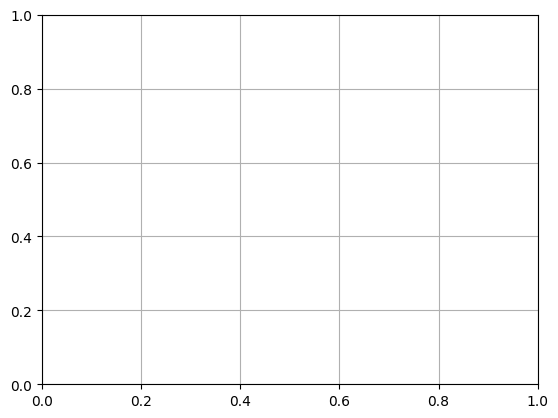

In [41]:
plt.grid(True)